# Этап 1. Исследовательский анализ


## Загрузка данных


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

def resolve_project_dir():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.home() / "Yandex_Sprint4",
    ]

    for candidate in candidates:
        if (candidate / "data" / "dish.csv").exists():
            return candidate.resolve()

    raise FileNotFoundError("Не найдена папка data с файлом dish.csv")

PROJECT_DIR = resolve_project_dir()
DATA_DIR = PROJECT_DIR / "data"

print(f"PROJECT_DIR: {PROJECT_DIR}")

# Читаем основные таблицы проекта.
dish = pd.read_csv(DATA_DIR / "dish.csv")
ingredients = pd.read_csv(DATA_DIR / "ingredients.csv")

dish.shape, ingredients.shape


PROJECT_DIR: /home/ubuntu/Yandex_Sprint4


((3262, 5), (555, 2))

In [2]:
# Собираем словарь id -> название ингредиента.
ingredients_map = dict(zip(ingredients["id"].astype(int), ingredients["ingr"]))

def replace_ingredient_ids(raw_value):
    ingredients_list = []

    for item in str(raw_value).split(";"):
        if not item:
            continue

        # Убираем служебный префикс и получаем id ингредиента.
        item_id = item.replace("ingr_", "").lstrip("0")
        item_id = int(item_id) if item_id else 0

        if item_id in ingredients_map:
            ingredients_list.append(ingredients_map[item_id])

    return ", ".join(ingredients_list) if ingredients_list else "unknown"


# Готовим текстовый признак и путь до изображения.
dish["ingredients_text"] = dish["ingredients"].apply(replace_ingredient_ids)
dish["image_path"] = dish["dish_id"].apply(
    lambda dish_id: DATA_DIR / "images" / str(dish_id) / "rgb.png"
)

dish[["dish_id", "total_calories", "total_mass", "ingredients_text", "split"]].head()


,dish_id,total_calories,total_mass,ingredients_text,split
0,dish_1561662216,300.794281,193.0,"soy sauce, garlic, white rice, parsley, onions...",test
1,dish_1561662054,419.438782,292.0,"pepper, white rice, mixed greens, garlic, soy ...",train
2,dish_1562008979,382.936646,290.0,"jalapenos, lemon juice, pork, wheat berry, cab...",test
3,dish_1560455030,20.590000,103.0,"cherry tomatoes, cucumbers, baby carrots",train
4,dish_1558372433,74.360001,143.0,deprecated,train


## Первичный осмотр


In [3]:
# Смотрим, как распределены объекты по train и test.
display(dish["split"].value_counts())

# Проверяем диапазоны массы и калорийности.
display(dish[["total_calories", "total_mass"]].describe().T)

# Оцениваем связь между массой и калорийностью.
display(dish[["total_mass", "total_calories"]].corr())


split
train    2755
test      507
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
total_calories,3262.0,255.012738,219.637570,0.0,80.114996,209.110062,375.122963,3943.325195
total_mass,3262.0,214.980074,161.497428,1.0,92.000000,177.000000,305.000000,3051.000000


,total_mass,total_calories
total_mass,1.000000,0.759676
total_calories,0.759676,1.000000


## Визуализация


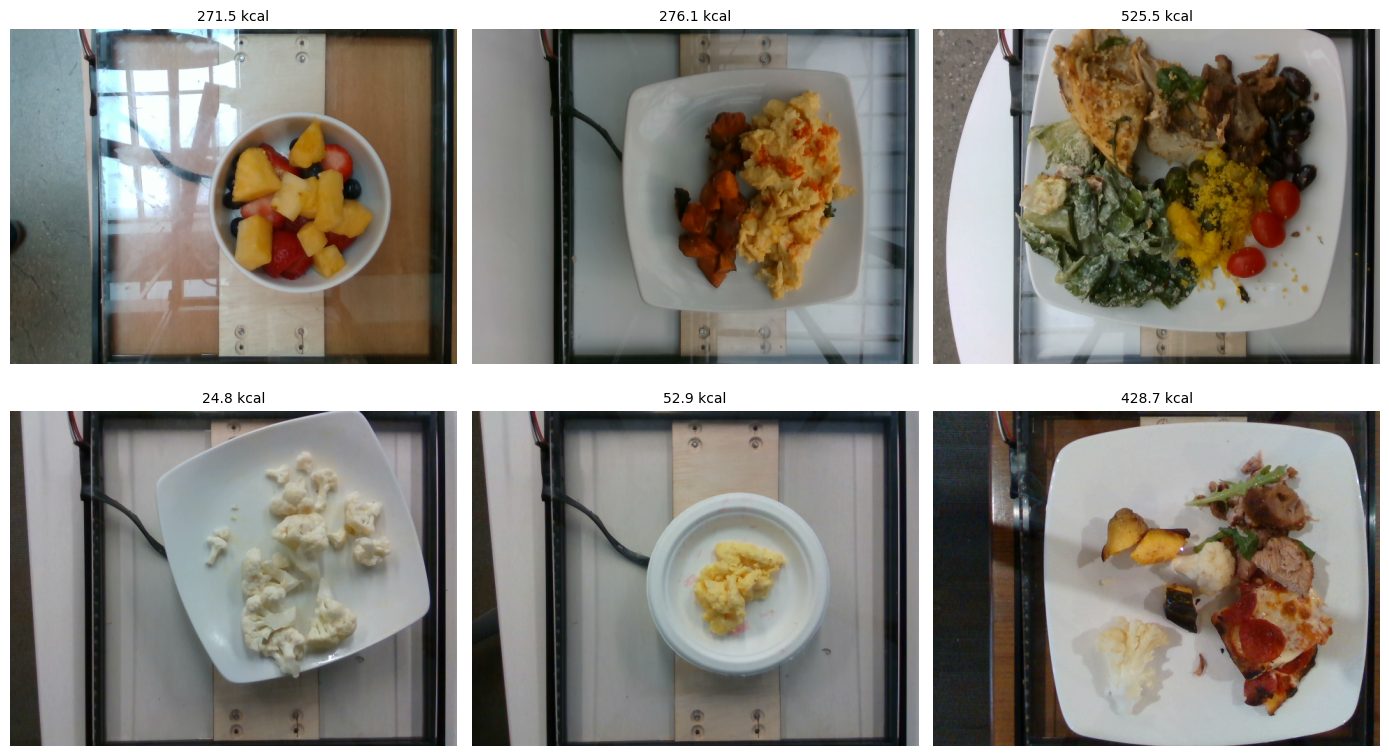

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

# Берем несколько случайных блюд и смотрим на изображения.
sample = dish.sample(6, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for axis, (_, row) in zip(axes.flatten(), sample.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    axis.imshow(image)
    axis.axis("off")
    axis.set_title(f"{row['total_calories']:.1f} kcal", fontsize=10)

plt.tight_layout()
plt.show()


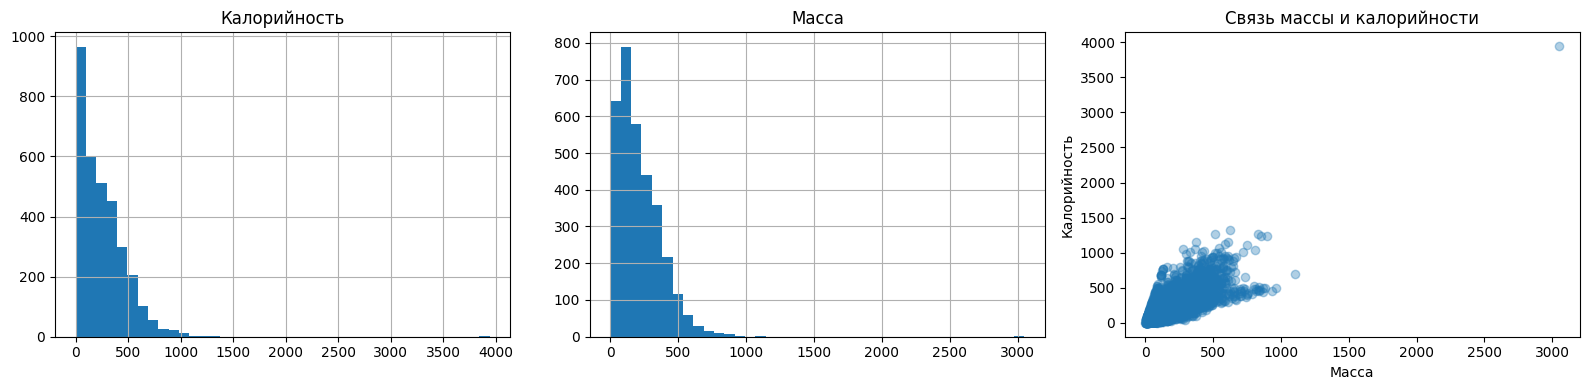

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Смотрим распределение целевого признака.
dish["total_calories"].hist(bins=40, ax=axes[0])
axes[0].set_title("Калорийность")

# Отдельно проверяем распределение массы порции.
dish["total_mass"].hist(bins=40, ax=axes[1])
axes[1].set_title("Масса")

# По диаграмме рассеяния оцениваем общую зависимость.
axes[2].scatter(
    dish["total_mass"],
    dish["total_calories"],
    alpha=0.35,
)
axes[2].set_xlabel("Масса")
axes[2].set_ylabel("Калорийность")
axes[2].set_title("Связь массы и калорийности")

plt.tight_layout()
plt.show()


## Выводы

- После подготовки данных в выборке осталось 3262 блюда: 2755 объектов в `train` и 507 объектов в `test`, поэтому объёма данных достаточно для построения базового мультимодального baseline.
- Распределение калорийности выраженно правостороннее: медиана составляет около 209 ккал, среднее — около 255 ккал, а максимум сильно уходит вправо. Это значит, что в данных есть небольшой хвост очень калорийных блюд.
- Почти 30% блюд содержат меньше 100 ккал, а объектов с калорийностью выше 900 ккал около 1.3%. Следовательно, модель будет чаще видеть блюда среднего диапазона, чем экстремально калорийные примеры.
- Масса порции заметно связана с калорийностью (`corr ≈ 0.76`), но одной массы недостаточно для точного прогноза: блюда похожей массы могут сильно отличаться по составу и калорийной плотности.
- Значит, для решения задачи логично объединить три источника информации: изображение блюда, текст ингредиентов и массу порции.


# Этап 2. Реализация пайплайна обучения


In [6]:
# Переходим в корень проекта и готовим рабочие папки.
%cd $PROJECT_DIR

(PROJECT_DIR / "scripts").mkdir(exist_ok=True)
(PROJECT_DIR / "artifacts").mkdir(exist_ok=True)

print(f"Текущая папка: {Path.cwd()}")


/home/ubuntu/Yandex_Sprint4
Текущая папка: /home/ubuntu/Yandex_Sprint4


/home/ubuntu/Yandex_Sprint4/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## config.py


In [7]:
%%writefile scripts/config.py
from dataclasses import dataclass
from pathlib import Path


# Опорные пути считаем относительно корня репозитория.
PROJECT_DIR = Path(__file__).resolve().parent.parent

# Все основные параметры обучения держим в одном конфиге.
@dataclass
class TrainConfig:
    DATA_DIR: str = str(PROJECT_DIR / "data")
    SAVE_PATH: str = str(PROJECT_DIR / "artifacts" / "best_model.pt")
    TEXT_MODEL_NAME: str = "distilbert-base-uncased"
    IMAGE_MODEL_NAME: str = "resnet18"
    IMAGE_SIZE: int = 224
    HIDDEN_DIM: int = 256
    DROPOUT: float = 0.15
    BATCH_SIZE: int = 4
    EPOCHS: int = 5
    TEXT_MAX_LENGTH: int = 128
    TEXT_LR: float = 2e-5
    IMAGE_LR: float = 1e-4
    CLASSIFIER_LR: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    VAL_SIZE: float = 0.15
    NUM_WORKERS: int = 2
    SEED: int = 42
    TEXT_MODEL_UNFREEZE: str = "transformer.layer.5"
    IMAGE_MODEL_UNFREEZE: str = "layer4"


Overwriting scripts/config.py


## dataset.py


In [8]:
%%writefile scripts/dataset.py
import os

import albumentations as A
import numpy as np
import pandas as pd
import torch
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset


def replace_ingredient_ids(raw_value, ingredients_map):
    ingredients = []

    for item in str(raw_value).split(";"):
        if not item:
            continue

        # Убираем служебный префикс и получаем числовой id ингредиента.
        item_id = item.replace("ingr_", "").lstrip("0")
        item_id = int(item_id) if item_id else 0

        if item_id in ingredients_map:
            ingredients.append(ingredients_map[item_id])

    return ", ".join(ingredients) if ingredients else "unknown"


def load_data(data_dir):
    # Читаем таблицы с блюдами и словарем ингредиентов.
    dish = pd.read_csv(os.path.join(data_dir, "dish.csv"))
    ingredients = pd.read_csv(os.path.join(data_dir, "ingredients.csv"))

    ingredients_map = dict(zip(ingredients["id"].astype(int), ingredients["ingr"]))

    # Переводим технические id ингредиентов в обычный текст.
    dish["ingredients_text"] = dish["ingredients"].apply(
        lambda value: replace_ingredient_ids(value, ingredients_map)
    )
    # Путь до изображения каждого блюда формируем сразу.
    dish["image_path"] = dish["dish_id"].apply(
        lambda dish_id: os.path.join(data_dir, "images", str(dish_id), "rgb.png")
    )
    dish["total_calories"] = dish["total_calories"].astype("float32")
    # Массу уменьшаем по масштабу перед подачей в модель.
    dish["total_mass"] = dish["total_mass"].astype("float32") / 1000

    # Оставляем только строки, для которых есть изображение.
    dish = dish[dish["image_path"].apply(os.path.exists)].reset_index(drop=True)
    return dish


def prepare_datasets(config):
    dataframe = load_data(config.DATA_DIR)

    # Тестовый сплит уже дан в датасете, train делим еще и на val.
    train_df = dataframe[dataframe["split"] == "train"].copy()
    test_df = dataframe[dataframe["split"] == "test"].copy()

    train_df, val_df = train_test_split(
        train_df,
        test_size=config.VAL_SIZE,
        random_state=config.SEED,
        shuffle=True,
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def get_transforms(config, ds_type="train"):
    if ds_type == "train":
        return A.Compose(
            [
                # Для обучения берем мягкие аугментации.
                A.Resize(height=config.IMAGE_SIZE, width=config.IMAGE_SIZE, p=1.0),
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225),
                ),
                ToTensorV2(),
            ]
        )

    return A.Compose(
        [
            A.Resize(height=config.IMAGE_SIZE, width=config.IMAGE_SIZE, p=1.0),
            A.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225),
            ),
            ToTensorV2(),
        ]
    )


class MultimodalDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # Изображения лежат во вложенных папках по dish_id.
        image = Image.open(row["image_path"]).convert("RGB")
        image = np.array(image)
        image = self.transform(image=image)["image"]

        return {
            "dish_id": row["dish_id"],
            "ingredients_text": row["ingredients_text"],
            "image": image,
            "mass": np.float32(row["total_mass"]),
            "target": np.float32(row["total_calories"]),
            "image_path": row["image_path"],
        }


def collate_fn(batch, tokenizer, max_length):
    text_batch = [item["ingredients_text"] for item in batch]

    # Токенизируем текстовые признаки в батче.
    text_input = tokenizer(
        text_batch,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    return {
        "dish_id": [item["dish_id"] for item in batch],
        "ingredients_text": text_batch,
        "input_ids": text_input["input_ids"],
        "attention_mask": text_input["attention_mask"],
        "image": torch.stack([item["image"] for item in batch]),
        "mass": torch.tensor(
            [item["mass"] for item in batch],
            dtype=torch.float32,
        ).unsqueeze(1),
        "target": torch.tensor(
            [item["target"] for item in batch],
            dtype=torch.float32,
        ),
        "image_path": [item["image_path"] for item in batch],
    }


load_dataset_frame = load_data


Overwriting scripts/dataset.py


## utils.py


In [9]:
%%writefile scripts/utils.py
import os
import random
import re
from functools import partial

import pandas as pd
import timm
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModel, AutoTokenizer

try:
    from .config import TrainConfig
    from .dataset import MultimodalDataset, collate_fn, get_transforms, prepare_datasets
except ImportError:
    from config import TrainConfig
    from dataset import MultimodalDataset, collate_fn, get_transforms, prepare_datasets


class BaseMultimodalModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Отдельно кодируем текст и изображение.
        self.text_model = AutoModel.from_pretrained(config.TEXT_MODEL_NAME)
        self.image_model = timm.create_model(
            config.IMAGE_MODEL_NAME,
            pretrained=True,
            num_classes=0,
        )

        self.text_proj = nn.Linear(
            self.text_model.config.hidden_size,
            config.HIDDEN_DIM,
        )
        self.image_proj = nn.Linear(
            self.image_model.num_features,
            config.HIDDEN_DIM,
        )

    def forward(self, input_ids, attention_mask, image):
        text_features = self.text_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).last_hidden_state[:, 0, :]
        image_features = self.image_model(image)

        text_emb = self.text_proj(text_features)
        image_emb = self.image_proj(image_features)
        return text_emb, image_emb


class MultimodalRegressor(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.base_model = BaseMultimodalModel(config)

        # На вход regressor подаем fusion-признак и массу порции.
        self.regressor = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM + 1, config.HIDDEN_DIM // 2),
            nn.LayerNorm(config.HIDDEN_DIM // 2),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.HIDDEN_DIM // 2, 1),
        )

    def forward(self, input_ids, attention_mask, image, mass):
        text_emb, image_emb = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
        )

        # Объединяем модальности через поэлементное произведение.
        fused_emb = text_emb * image_emb
        fused_emb = torch.cat([fused_emb, mass], dim=1)
        return self.regressor(fused_emb).squeeze(1)


def seed_everything(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def set_requires_grad(module, unfreeze_pattern="", verbose=False):
    if not unfreeze_pattern:
        for _, param in module.named_parameters():
            param.requires_grad = False
        return

    # Размораживаем только слои, которые подходят под шаблон.
    pattern = re.compile(unfreeze_pattern)

    for name, param in module.named_parameters():
        if pattern.search(name):
            param.requires_grad = True
            if verbose:
                print(f"Разморожен слой: {name}")
        else:
            param.requires_grad = False


def validate(model, val_loader, device, criterion):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for batch in val_loader:
            # Переносим батч на выбранное устройство.
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
                "image": batch["image"].to(device),
                "mass": batch["mass"].to(device),
            }
            targets = batch["target"].to(device)

            predictions = model(**inputs)
            loss = criterion(predictions, targets)

            batch_size = len(targets)
            total_loss += loss.item() * batch_size
            total_items += batch_size

    return total_loss / total_items


def train(config=None):
    if config is None:
        config = TrainConfig()

    # Фиксируем seed для воспроизводимости.
    seed_everything(config.SEED)
    os.makedirs(os.path.dirname(config.SAVE_PATH), exist_ok=True)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = MultimodalRegressor(config).to(device)
    tokenizer = AutoTokenizer.from_pretrained(config.TEXT_MODEL_NAME)

    set_requires_grad(
        model.base_model.text_model,
        config.TEXT_MODEL_UNFREEZE,
    )
    set_requires_grad(
        model.base_model.image_model,
        config.IMAGE_MODEL_UNFREEZE,
    )

    # В оптимизатор включаем все обучаемые части модели.
    optimizer = AdamW(
        [
            {"params": model.base_model.text_model.parameters(), "lr": config.TEXT_LR},
            {"params": model.base_model.image_model.parameters(), "lr": config.IMAGE_LR},
            {"params": model.base_model.text_proj.parameters(), "lr": config.CLASSIFIER_LR},
            {"params": model.base_model.image_proj.parameters(), "lr": config.CLASSIFIER_LR},
            {"params": model.regressor.parameters(), "lr": config.CLASSIFIER_LR},
        ],
        weight_decay=config.WEIGHT_DECAY,
    )
    criterion = nn.L1Loss()

    train_df, val_df, _ = prepare_datasets(config)

    train_loader = DataLoader(
        MultimodalDataset(train_df, get_transforms(config)),
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=partial(
            collate_fn,
            tokenizer=tokenizer,
            max_length=config.TEXT_MAX_LENGTH,
        ),
    )
    val_loader = DataLoader(
        MultimodalDataset(val_df, get_transforms(config, ds_type="val")),
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=partial(
            collate_fn,
            tokenizer=tokenizer,
            max_length=config.TEXT_MAX_LENGTH,
        ),
    )

    best_mae = float("inf")
    history = []

    for epoch in range(config.EPOCHS):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            # Собираем входы модели из текстовой и визуальной части.
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
                "image": batch["image"].to(device),
                "mass": batch["mass"].to(device),
            }
            targets = batch["target"].to(device)

            optimizer.zero_grad()
            predictions = model(**inputs)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        val_mae = validate(model, val_loader, device, criterion)
        train_mae = total_loss / len(train_loader)

        history.append(
            {
                "epoch": epoch + 1,
                "train_mae": train_mae,
                "val_mae": val_mae,
            }
        )

        print(
            f"Epoch {epoch + 1}/{config.EPOCHS} | "
            f"train_mae={train_mae:.4f} | "
            f"val_mae={val_mae:.4f}"
        )

        if val_mae < best_mae:
            best_mae = val_mae
            # Сохраняем лучший чекпоинт по валидационной метрике.
            torch.save(model.state_dict(), config.SAVE_PATH)

    return pd.DataFrame(history)


def predict_on_test(config=None):
    if config is None:
        config = TrainConfig()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    _, _, test_df = prepare_datasets(config)
    tokenizer = AutoTokenizer.from_pretrained(config.TEXT_MODEL_NAME)

    test_loader = DataLoader(
        MultimodalDataset(test_df, get_transforms(config, ds_type="test")),
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=partial(
            collate_fn,
            tokenizer=tokenizer,
            max_length=config.TEXT_MAX_LENGTH,
        ),
    )

    model = MultimodalRegressor(config).to(device)
    model.load_state_dict(torch.load(config.SAVE_PATH, map_location=device))
    criterion = nn.L1Loss()
    predictions = []

    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for batch in test_loader:
            # На тесте дополнительно сохраняем предсказания для анализа ошибок.
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
                "image": batch["image"].to(device),
                "mass": batch["mass"].to(device),
            }
            targets = batch["target"].to(device)

            outputs = model(**inputs)
            loss = criterion(outputs, targets)

            batch_size = len(targets)
            total_loss += loss.item() * batch_size
            total_items += batch_size

            errors = torch.abs(outputs - targets)

            for i in range(batch_size):
                predictions.append(
                    {
                        "dish_id": batch["dish_id"][i],
                        "ingredients_text": batch["ingredients_text"][i],
                        "target": targets[i].item(),
                        "prediction": outputs[i].item(),
                        "absolute_error": errors[i].item(),
                        "image_path": batch["image_path"][i],
                    }
                )

    metrics = {"mae": total_loss / total_items}
    predictions = pd.DataFrame(predictions).sort_values(
        "absolute_error",
        ascending=False,
    )

    return metrics, predictions.reset_index(drop=True)


def show_hard_examples(predictions, top_n=5):
    import matplotlib.pyplot as plt

    hard_examples = predictions.head(top_n)
    fig, axes = plt.subplots(top_n, 1, figsize=(12, 4 * top_n))

    if top_n == 1:
        axes = [axes]

    for axis, (_, row) in zip(axes, hard_examples.iterrows()):
        image = plt.imread(row["image_path"])

        axis.imshow(image)
        axis.axis("off")
        axis.set_title(
            f"{row['dish_id']} | true={row['target']:.1f} | "
            f"pred={row['prediction']:.1f} | "
            f"abs_error={row['absolute_error']:.1f}",
            fontsize=11,
        )
        axis.text(
            0.0,
            -0.12,
            row["ingredients_text"],
            transform=axis.transAxes,
            fontsize=9,
            wrap=True,
            va="top",
        )

    plt.tight_layout()
    plt.show()


Overwriting scripts/utils.py


## Импорт и конфигурация обучения


In [10]:
import sys

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from scripts.config import TrainConfig
from scripts.utils import predict_on_test, show_hard_examples, train

# Используем корпус данных и папку артефактов внутри репозитория.
cfg = TrainConfig(
    DATA_DIR=str(PROJECT_DIR / "data"),
    SAVE_PATH=str(PROJECT_DIR / "artifacts" / "best_model.pt"),
    BATCH_SIZE=4,
    EPOCHS=5,
)

cfg


/home/ubuntu/Yandex_Sprint4/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TrainConfig(DATA_DIR='/home/ubuntu/Yandex_Sprint4/data', SAVE_PATH='/home/ubuntu/Yandex_Sprint4/artifacts/best_model.pt', TEXT_MODEL_NAME='distilbert-base-uncased', IMAGE_MODEL_NAME='resnet18', IMAGE_SIZE=224, HIDDEN_DIM=256, DROPOUT=0.15, BATCH_SIZE=4, EPOCHS=5, TEXT_MAX_LENGTH=128, TEXT_LR=2e-05, IMAGE_LR=0.0001, CLASSIFIER_LR=0.001, WEIGHT_DECAY=0.0001, VAL_SIZE=0.15, NUM_WORKERS=2, SEED=42, TEXT_MODEL_UNFREEZE='transformer.layer.5', IMAGE_MODEL_UNFREEZE='layer4')

# Этап 3. Обучение модели


In [11]:
import sys
from pathlib import Path

import torch

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from scripts.config import TrainConfig
from scripts.utils import train

# Еще раз собираем конфиг прямо перед обучением.
cfg = TrainConfig(
    DATA_DIR=str(PROJECT_DIR / "data"),
    SAVE_PATH=str(PROJECT_DIR / "artifacts" / "best_model.pt"),
    BATCH_SIZE=4,
    EPOCHS=5,
)

Path(cfg.SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)

# Сразу проверяем, видит ли среда GPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")

cfg


Устройство: cuda


TrainConfig(DATA_DIR='/home/ubuntu/Yandex_Sprint4/data', SAVE_PATH='/home/ubuntu/Yandex_Sprint4/artifacts/best_model.pt', TEXT_MODEL_NAME='distilbert-base-uncased', IMAGE_MODEL_NAME='resnet18', IMAGE_SIZE=224, HIDDEN_DIM=256, DROPOUT=0.15, BATCH_SIZE=4, EPOCHS=5, TEXT_MAX_LENGTH=128, TEXT_LR=2e-05, IMAGE_LR=0.0001, CLASSIFIER_LR=0.001, WEIGHT_DECAY=0.0001, VAL_SIZE=0.15, NUM_WORKERS=2, SEED=42, TEXT_MODEL_UNFREEZE='transformer.layer.5', IMAGE_MODEL_UNFREEZE='layer4')

Epoch 1/5 | train_mae=223.3201 | val_mae=199.0645
Epoch 2/5 | train_mae=162.6967 | val_mae=133.0101
Epoch 3/5 | train_mae=117.5848 | val_mae=100.0157
Epoch 4/5 | train_mae=94.5932 | val_mae=82.8034
Epoch 5/5 | train_mae=82.0005 | val_mae=79.1982


,epoch,train_mae,val_mae
0,1,223.320054,199.064519
1,2,162.696745,133.010092
2,3,117.584808,100.015728
3,4,94.593204,82.803399
4,5,82.000484,79.198218


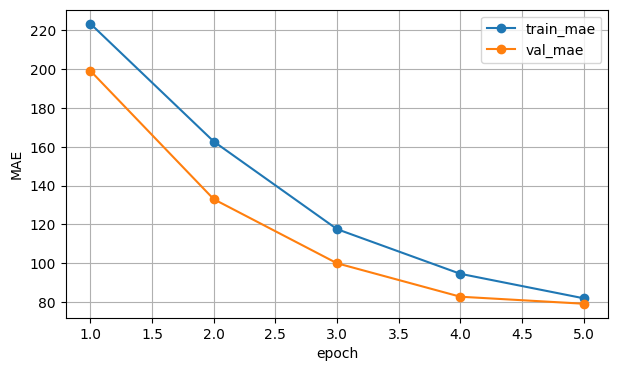

In [12]:
import matplotlib.pyplot as plt

# Если состояние kernel сбросилось, повторно подгружаем train и cfg.
if "train" not in globals() or "cfg" not in globals():
    import sys
    from pathlib import Path

    if str(PROJECT_DIR) not in sys.path:
        sys.path.append(str(PROJECT_DIR))

    from scripts.config import TrainConfig
    from scripts.utils import train

    cfg = TrainConfig(
        DATA_DIR=str(PROJECT_DIR / "data"),
        SAVE_PATH=str(PROJECT_DIR / "artifacts" / "best_model.pt"),
        BATCH_SIZE=4,
        EPOCHS=5,
    )
    Path(cfg.SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)

# Запускаем обучение и сохраняем историю метрик по эпохам.
history = train(cfg)
display(history)

# Строим график ошибки на train и validation.
history.plot(
    x="epoch",
    y=["train_mae", "val_mae"],
    marker="o",
    figsize=(7, 4),
)
plt.ylabel("MAE")
plt.grid(True)
plt.show()


## Выводы

- За 5 эпох модель устойчиво улучшила качество: `train_mae` снизилась с 223.3 до 82.0, а `val_mae` — с 199.1 до 79.2. Значит, обучение действительно идет в правильную сторону, а модель извлекает полезный сигнал из данных.
- Валидационная ошибка убывает почти на каждой эпохе вместе с тренировочной, поэтому по текущему прогону явных признаков переобучения не наблюдается.
- Разница между финальными `train_mae` и `val_mae` небольшая, значит модель не просто запоминает обучающую выборку, а сохраняет способность обобщать на отложенные данные.
- Лучший чекпоинт сохраняется в `artifacts/best_model.pt`, поэтому этап инференса можно воспроизводить отдельно уже по готовому артефакту модели.


# Этап 4. Валидация качества


In [13]:
# Если kernel был перезапущен, заново собираем cfg и импортируем инференс.
if "cfg" not in globals() or "predict_on_test" not in globals():
    import sys

    if str(PROJECT_DIR) not in sys.path:
        sys.path.append(str(PROJECT_DIR))

    from scripts.config import TrainConfig
    from scripts.utils import predict_on_test

    cfg = TrainConfig(
        DATA_DIR=str(PROJECT_DIR / "data"),
        SAVE_PATH=str(PROJECT_DIR / "artifacts" / "best_model.pt"),
        BATCH_SIZE=4,
        EPOCHS=5,
    )

# Получаем метрику на test и сохраняем предсказания.
test_metrics, test_predictions = predict_on_test(cfg)

print(f"Test MAE: {test_metrics['mae']:.2f}")
display(test_predictions.head())


Test MAE: 83.02


,dish_id,ingredients_text,target,prediction,absolute_error,image_path
0,dish_1558375886,"almonds, sausage, grapes",1050.511108,407.272919,643.238159,/home/ubuntu/Yandex_Sprint4/data/images/dish_1...
1,dish_1558373159,"sausage, deprecated, almonds",1013.337036,403.998474,609.338562,/home/ubuntu/Yandex_Sprint4/data/images/dish_1...
2,dish_1563478751,"cream, mushroom, spinach (raw), olive oil, pas...",950.395081,397.135681,553.259399,/home/ubuntu/Yandex_Sprint4/data/images/dish_1...
3,dish_1566328831,"pizza, cherry tomatoes, chicken, pineapple, ol...",941.609985,409.626495,531.983521,/home/ubuntu/Yandex_Sprint4/data/images/dish_1...
4,dish_1566328805,"cherry tomatoes, pizza, chicken, pineapple",927.809998,409.864227,517.945801,/home/ubuntu/Yandex_Sprint4/data/images/dish_1...


,dish_id,target,prediction,absolute_error,ingredients_text
0,dish_1558375886,1050.511108,407.272919,643.238159,"almonds, sausage, grapes"
1,dish_1558373159,1013.337036,403.998474,609.338562,"sausage, deprecated, almonds"
2,dish_1563478751,950.395081,397.135681,553.259399,"cream, mushroom, spinach (raw), olive oil, pas..."
3,dish_1566328831,941.609985,409.626495,531.983521,"pizza, cherry tomatoes, chicken, pineapple, ol..."
4,dish_1566328805,927.809998,409.864227,517.945801,"cherry tomatoes, pizza, chicken, pineapple"


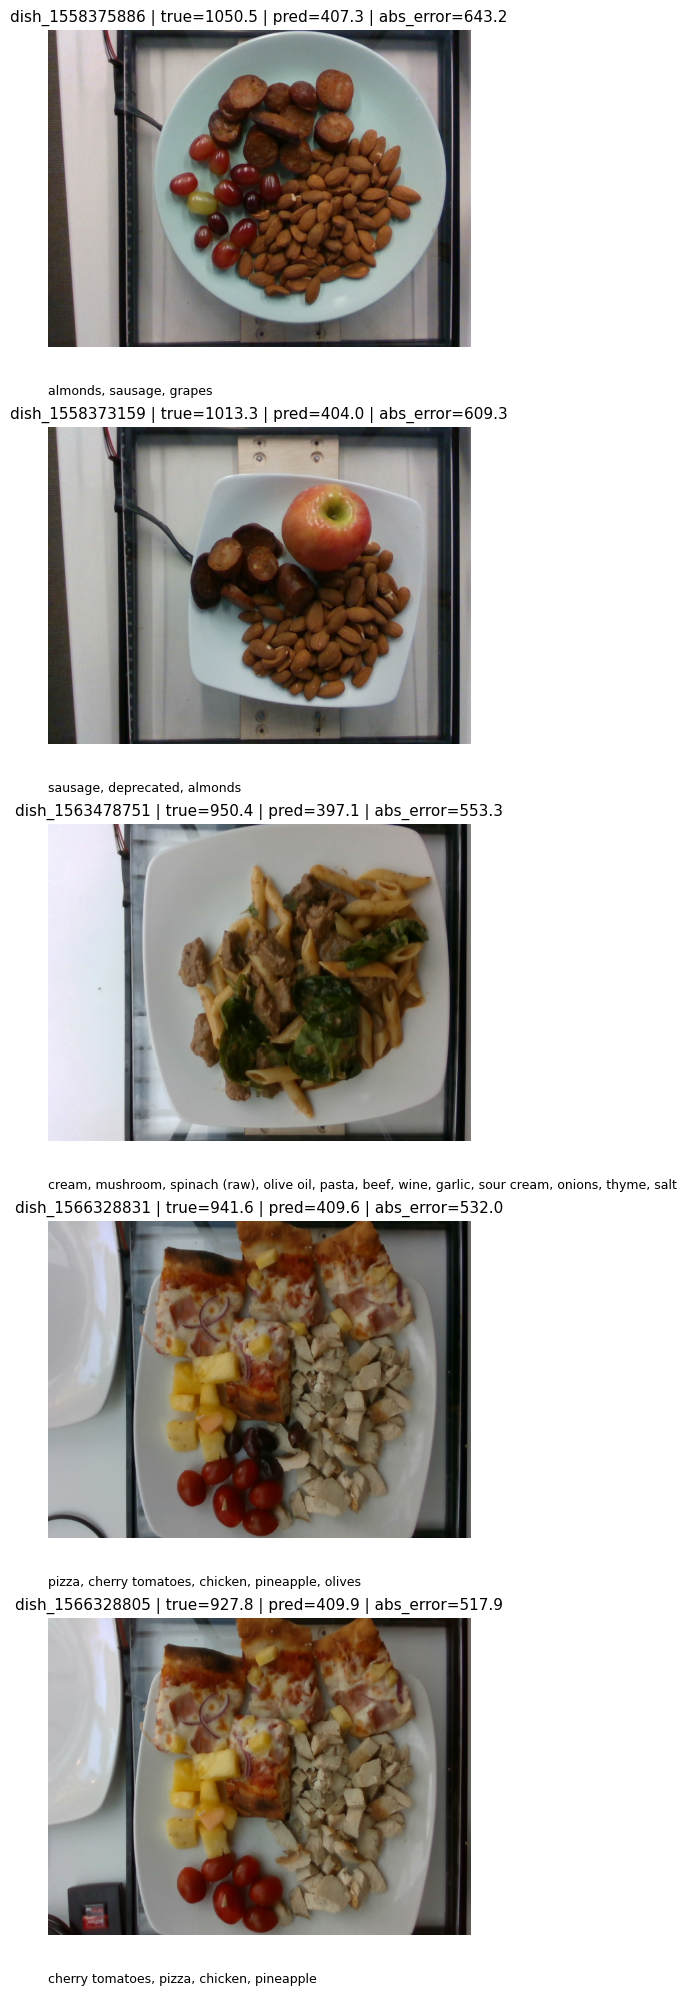

In [14]:
# Если предсказаний нет в памяти, сначала пересчитываем test.
if "test_predictions" not in globals():
    if "cfg" not in globals() or "predict_on_test" not in globals():
        import sys

        if str(PROJECT_DIR) not in sys.path:
            sys.path.append(str(PROJECT_DIR))

        from scripts.config import TrainConfig
        from scripts.utils import predict_on_test

        cfg = TrainConfig(
            DATA_DIR=str(PROJECT_DIR / "data"),
            SAVE_PATH=str(PROJECT_DIR / "artifacts" / "best_model.pt"),
            BATCH_SIZE=4,
            EPOCHS=5,
        )

    test_metrics, test_predictions = predict_on_test(cfg)

if "show_hard_examples" not in globals():
    import sys

    if str(PROJECT_DIR) not in sys.path:
        sys.path.append(str(PROJECT_DIR))

    from scripts.utils import show_hard_examples

# Смотрим на объекты с наибольшей абсолютной ошибкой.
top_errors = test_predictions.head(5).copy()
display(
    top_errors[
        ["dish_id", "target", "prediction", "absolute_error", "ingredients_text"]
    ]
)

# Визуально разбираем самые сложные примеры.
show_hard_examples(test_predictions, top_n=5)


## Причины ошибок модели

- На `test` модель получила `MAE = 83.02`, что близко к финальной `val_mae = 79.20`. Значит, качество на тестовой выборке в целом согласуется с результатом валидации и не проседает критически.
- Все топ-5 самых тяжёлых примеров относятся к очень калорийным блюдам: истинные значения лежат примерно в диапазоне от 928 до 1051 ккал, тогда как предсказания модели сгруппированы около 397–410 ккал. Это указывает на систематическое занижение верхнего хвоста распределения.
- Наиболее вероятная причина — дисбаланс по целевому признаку. Очень калорийные блюда редки, поэтому модель чаще обучается на умеренных значениях и тяготеет к более безопасным предсказаниям среднего диапазона.
- Дополнительная причина — сложный состав тяжёлых примеров. В топе ошибок встречаются комбинации `sausage`, `almonds`, `cream`, `pizza`, `olive oil`, `chicken`, `pineapple`, то есть ингредиенты с высокой калорийной плотностью, которые трудно корректно взвесить только по одному изображению или массе порции.
- В одном из самых трудных примеров присутствует токен `deprecated`, поэтому текстовый признак местами шумный и не всегда полноценно описывает состав блюда. Это тоже может ухудшать точность прогноза.


## Выводы

- Ноутбук закрывает полный цикл проекта: EDA, запись воспроизводимого кода обучения в `.py`-файлы, запуск `train(cfg)`, инференс на `test` и анализ самых тяжёлых ошибок модели.
- По текущему прогону baseline-модель обучается стабильно: `val_mae` к пятой эпохе снижается до 79.20, а на тесте достигается `MAE = 83.02`, то есть качество на новых данных остается сопоставимым с валидацией.
- Главный источник ошибок — редкие очень калорийные блюда. Значит, основной резерв улучшения качества связан не с базовой работоспособностью пайплайна, а с более сильной обработкой хвоста распределения и сложных составных блюд.
